In [128]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12


In [129]:
class LinearRegressionScratch:
    def __init__(self, alpha=0.0):
        """
        使用岭回归,加入L2正则化惩罚。
        在计算残差平方和时,加上参数向量到原点的距离，让残差平方和偏大。
        当正则化强度为0时，退化为普通的多元线性回归
        这一版模型中不再考虑不带截矩的情况
        """
        self.B1 = None      # 带截距
        self.alpha = alpha

    def regress(self, X, Y):
        n, p = X.shape

        # 带截距.惩罚除截距外的所有特征
        X1 = np.column_stack([np.ones(n), X])          
        # 构造惩罚矩阵：第一行第一列为0（截距项不惩罚），其余对角线为 alpha
        penalty_matrix = self.alpha * np.eye(p + 1)
        penalty_matrix[0, 0] = 0.0

        #经公式推导， 加入正则化后的正规方程如下
        self.B1 = np.linalg.inv(X1.T @ X1 + penalty_matrix) @ (X1.T @ Y)

    def predict(self, X):
        X_b = np.column_stack([np.ones(len(X)), X])
        return X_b @ self.B1

    def evaluate(self, X, Y):
        Y_hat = self.predict(X)
        Q = Y - Y_hat
        Q2 = np.sum(Q ** 2)
        R2 = 1 - Q2 / np.sum((Y - np.mean(Y)) ** 2)
        return Q2, R2

In [130]:
#数据加载与划分
housing = datasets.fetch_california_housing()
X, Y = housing.data, housing.target
feature_names = housing.feature_names
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# 数据标准化
train_mean = np.mean(X_train, axis=0)
train_std  = np.std(X_train, axis=0, ddof=1)
train_std[train_std == 0] = 1.0      # 避免常数特征导致除零
X_train = (X_train - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std

# 尝试不同的正则化强度
alphas = [0, 0.01, 0.1, 1.0, 10.0, 100.0]
train_r2_list = []
test_r2_list = []
coefs_path = []   # 记录每个正则化强度下带截距模型的特征系数

for a in alphas:
    model = LinearRegressionScratch(alpha=a)
    model.regress(X_train, Y_train)

    # 评估模型的R2
    _, r2_train = model.evaluate(X_train, Y_train)
    _, r2_test  = model.evaluate(X_test, Y_test)

    train_r2_list.append(r2_train)
    test_r2_list.append(r2_test)
    coefs_path.append(model.B1[1:])   

    print(f"alpha={a:.2f} | Train R2={r2_train:.4f} | Test R2={r2_test:.4f}")

coefs_path = np.array(coefs_path)


alpha=0.00 | Train R2=0.6126 | Test R2=0.5758
alpha=0.01 | Train R2=0.6126 | Test R2=0.5758
alpha=0.10 | Train R2=0.6126 | Test R2=0.5758
alpha=1.00 | Train R2=0.6126 | Test R2=0.5758
alpha=10.00 | Train R2=0.6125 | Test R2=0.5761
alpha=100.00 | Train R2=0.6120 | Test R2=0.5778


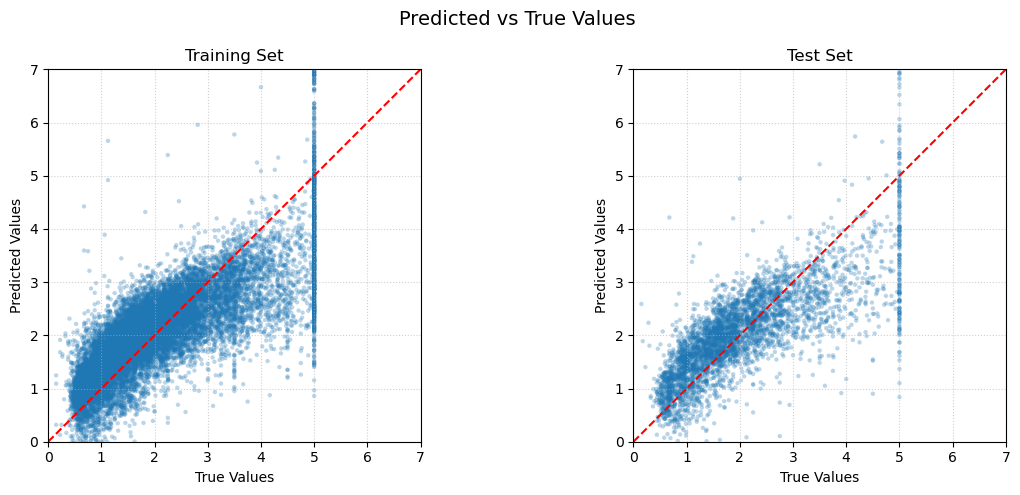

In [131]:
'''
图1 真实值与预测值对比图
横纵坐标分别为预测值与真实值。拟合效果越好，则散点图应趋向一条直线
'''


y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# ---------- 合并图1和图2：预测值 vs 真实值（训练 + 测试）----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 图1：训练集
axes[0].scatter(Y_train, y_train_pred, alpha=0.3, edgecolor='none', s=10)
axes[0].plot([0, 7], [0, 7], 'r--', linewidth=1.5)   # y=x 参考线，范围固定为[0,7]
axes[0].set_xlim(0, 7)
axes[0].set_ylim(0, 7)
axes[0].set_xlabel('True Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Training Set')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].set_aspect('equal', adjustable='box')

# 图2：测试集
axes[1].scatter(Y_test, y_test_pred, alpha=0.3, edgecolor='none', s=10)
axes[1].plot([0, 7], [0, 7], 'r--', linewidth=1.5)
axes[1].set_xlim(0, 7)
axes[1].set_ylim(0, 7)
axes[1].set_xlabel('True Values')
axes[1].set_ylabel('Predicted Values')
axes[1].set_title('Test Set')
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].set_aspect('equal', adjustable='box')

fig.suptitle('Predicted vs True Values', fontsize=14)
plt.tight_layout()
plt.show()



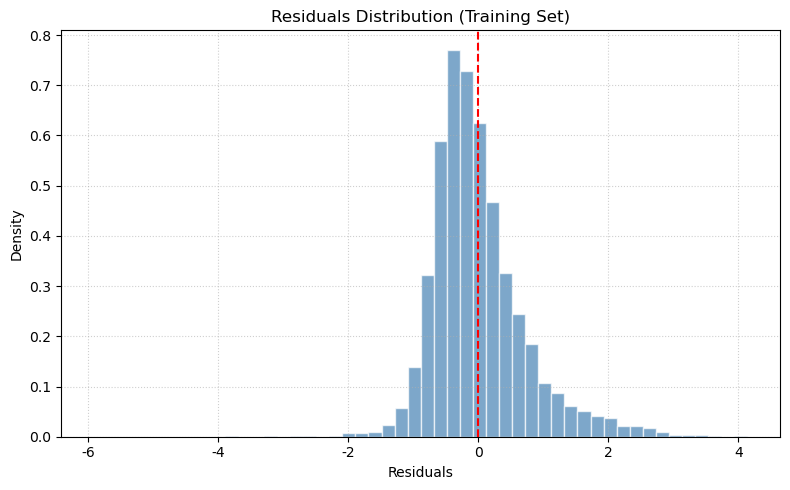

In [132]:
'''
图2. 残差分布直方图
图中可看出，对于绝大部分样本，其计算出的残差都在较小范围内
'''
residuals_train = Y_train - y_train_pred
plt.figure(figsize=(8, 5))
plt.hist(residuals_train, bins=50, density=True, alpha=0.7, color='steelblue',
         edgecolor='white')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.title('Residuals Distribution (Training Set)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()